In [12]:
#%pip install pandas numpy seaborn matplotlib
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Read csv

In [13]:
# Read csv
df = pd.read_csv('../data/processed/candor_dataset_clean.csv')
#print(df)

# Make a pair dataset by deleting the lines with the same call_id

In [14]:
# Make a pair dataset by deleting the lines with the same call_id
df_pair = df.drop_duplicates(subset=['call_id'])
df_pair = df_pair.reset_index(drop=True)

# Extract necessary parameters:
df_subset = df_pair.filter(
  items=['speech_activity_actor', 'speech_activity_partner', 'how_enjoyable_actor', 'how_enjoyable_partner']
  )

# Add other columns
df_subset['speech_activity_ave'] = (df_subset['speech_activity_actor'] + df_subset['speech_activity_partner'])/2
df_subset['speech_activity_diff'] = df_subset['speech_activity_actor'] - df_subset['speech_activity_partner']
df_subset['speech_activity_abs'] = abs(df_subset['speech_activity_diff'])

df_subset['how_enjoyable_ave'] = (df_subset['how_enjoyable_actor'] + df_subset['how_enjoyable_partner'])/2
df_subset['how_enjoyable_diff'] = df_subset['how_enjoyable_actor'] - df_subset['how_enjoyable_partner']
df_subset['how_enjoyable_abs'] = abs(df_subset['how_enjoyable_diff'])

#print(df_subset)

# Make a 4×4 correlation map

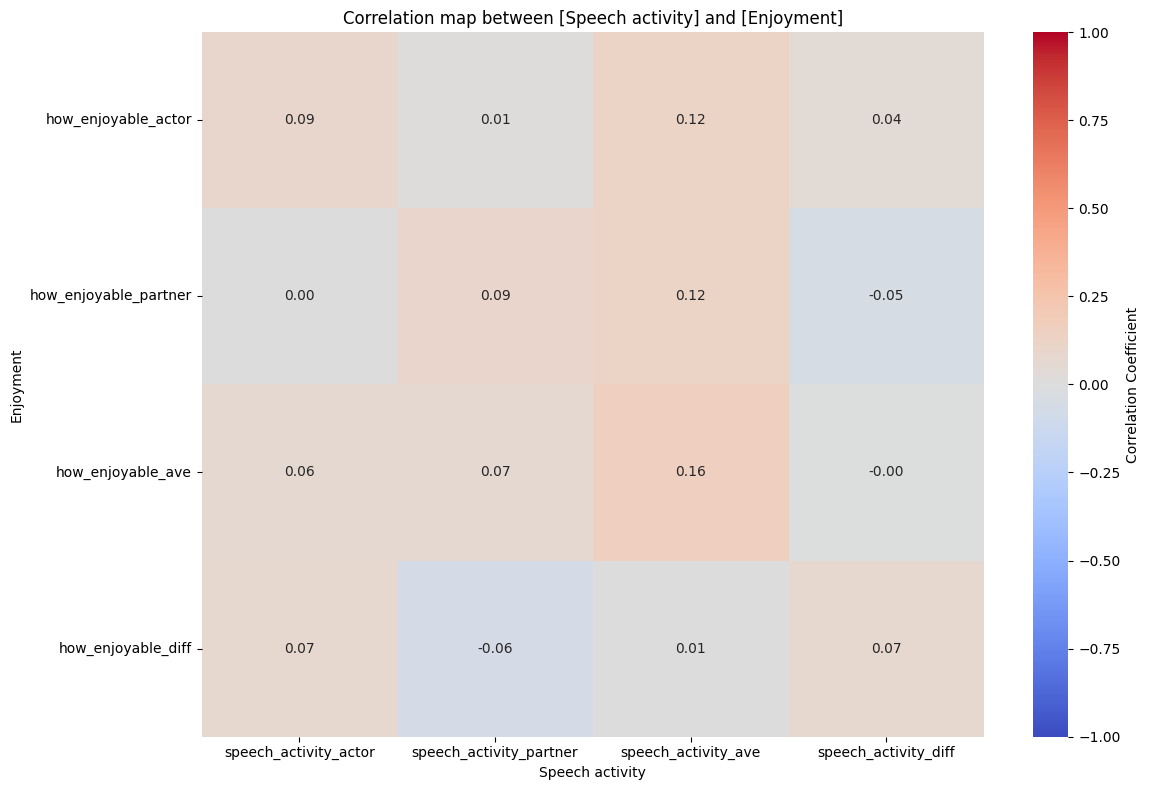

In [15]:
# Make a 4×4 correlation map
src_cols = ['speech_activity_actor', 'speech_activity_partner', 'speech_activity_ave', 'speech_activity_diff']
tar_cols = ['how_enjoyable_actor', 'how_enjoyable_partner', 'how_enjoyable_ave', 'how_enjoyable_diff']
corr_subset = df_subset.corr().loc[tar_cols, src_cols]
#print(corr_subset)

plt.figure(figsize=(12,8))
sns.heatmap(
  corr_subset,
  annot=True,
  cmap='coolwarm',
  fmt=".2f",
  vmin=-1, vmax=1,
  center=0,
  cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation map between [Speech activity] and [Enjoyment]")
plt.xlabel("Speech activity")
plt.ylabel("Enjoyment")

plt.tight_layout()
plt.show()

# Make four regressions

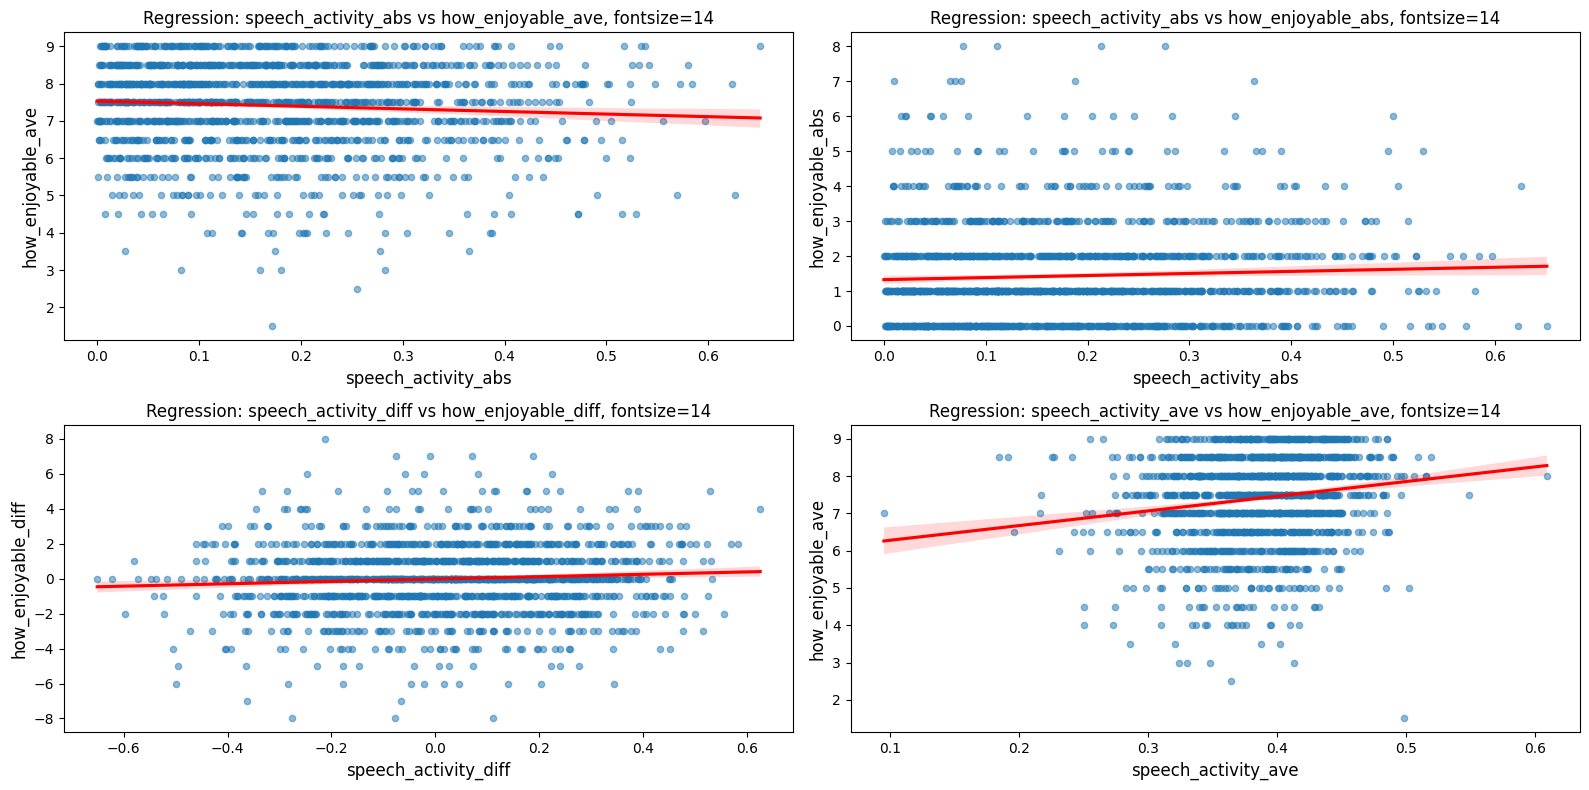

In [16]:
# Make four regressions
# H3-1 : lower activity abs -> higher enjoyable ave
# H3-2 : lower activity abs -> lower enjoyable abs
# H3-3 : higher activity diff -> higher enjoyable diff
# H3-4 : higher activity ave -> higher enjoyable ave

pairs = [('speech_activity_abs', 'how_enjoyable_ave'),
          ('speech_activity_abs', 'how_enjoyable_abs'), 
          ('speech_activity_diff', 'how_enjoyable_diff'), 
          ('speech_activity_ave', 'how_enjoyable_ave')]

fig, axes = plt.subplots(2, 2, figsize=(16,8))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(pairs):
  sns.regplot(
    data=df_subset,
    x=col_x,
    y=col_y,
    ax=axes[i],
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': 'red'},
    ci=95
  )

  axes[i].set_title(f"Regression: {col_x} vs {col_y}, fontsize=14")
  axes[i].set_xlabel(col_x, fontsize=12)
  axes[i].set_ylabel(col_y, fontsize=12)

plt.tight_layout()
plt.show()